What this Dataset contains:-

1)  Column ->                       Meaning
     - Type ->                       Machine type (L/M/H)
     - Air temperature [K] ->        Air temp in Kelvin
     - Process temperature [K] ->    Process temp
     - Rotational speed [rpm] ->     Speed of machine
     - Torque [Nm]  ->               Torque applied
     - Tool wear [min]  ->           Minutes of tool usage — this is your lifetime variable
     - Machine failure  ->           0 = working, 1 = failed
     - TWF/HDF/PWF/OSF/RNF ->        Type of failure

# Reliability & Survival Analysis of Industrial Equipment
### Statistical Study of Machine Failure Patterns

## Objective
To apply reliability theory and statistical inference 
on real industrial failure data — studying failure 
distributions, survival functions, and hypothesis testing.

Motivated by research on Statistical Inference for 
lifetime distributions (Kayal et al., 2019–2025)

## Dataset
AI4I 2020 Predictive Maintenance Dataset — Kaggle
10,000 machine observations with failure records

## Tools
Python | Pandas | NumPy | Matplotlib | Seaborn | Scipy

In [1]:
import pandas as pd  # for tables/dataframes
import numpy as np   # for math/arrays
import matplotlib.pyplot as plt   # for basic plots
import seaborn as sns   # for prettier plots
from scipy import stats  # for statistics (KS test, T-test, Chi-square)
import warnings
warnings.filterwarnings('ignore')
plt.style.use('seaborn-v0_8')

In [2]:
# Load data
df = pd.read_csv('../datasets/ai4i2020.csv')
df

,UDI,Product ID,Type,Air temperature [K],Process temperature [K],Rotational speed [rpm],Torque [Nm],Tool wear [min],Machine failure,TWF,HDF,PWF,OSF,RNF
0,1,M14860,M,298.1,308.6,1551,42.8,0,0,0,0,0,0,0
1,2,L47181,L,298.2,308.7,1408,46.3,3,0,0,0,0,0,0
2,3,L47182,L,298.1,308.5,1498,49.4,5,0,0,0,0,0,0
3,4,L47183,L,298.2,308.6,1433,39.5,7,0,0,0,0,0,0
4,5,L47184,L,298.2,308.7,1408,40.0,9,0,0,0,0,0,0
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
9995,9996,M24855,M,298.8,308.4,1604,29.5,14,0,0,0,0,0,0
9996,9997,H39410,H,298.9,308.4,1632,31.8,17,0,0,0,0,0,0
9997,9998,M24857,M,299.0,308.6,1645,33.4,22,0,0,0,0,0,0
9998,9999,H39412,H,299.0,308.7,1408,48.5,25,0,0,0,0,0,0


In [3]:
# Basic look
print("Dataset Shape:", df.shape)
print("\nColumn Names:")
print(df.columns.tolist())
print("\nFirst 5 rows:")
df.head()

Dataset Shape: (10000, 14)

Column Names:
['UDI', 'Product ID', 'Type', 'Air temperature [K]', 'Process temperature [K]', 'Rotational speed [rpm]', 'Torque [Nm]', 'Tool wear [min]', 'Machine failure', 'TWF', 'HDF', 'PWF', 'OSF', 'RNF']

First 5 rows:


,UDI,Product ID,Type,Air temperature [K],Process temperature [K],Rotational speed [rpm],Torque [Nm],Tool wear [min],Machine failure,TWF,HDF,PWF,OSF,RNF
0,1,M14860,M,298.1,308.6,1551,42.8,0,0,0,0,0,0,0
1,2,L47181,L,298.2,308.7,1408,46.3,3,0,0,0,0,0,0
2,3,L47182,L,298.1,308.5,1498,49.4,5,0,0,0,0,0,0
3,4,L47183,L,298.2,308.6,1433,39.5,7,0,0,0,0,0,0
4,5,L47184,L,298.2,308.7,1408,40.0,9,0,0,0,0,0,0


In [4]:
# Understanding Data
# Data types
print("Data Types:")
print(df.dtypes)
print("\nMissing Values:")
print(df.isnull().sum())

Data Types:
UDI                          int64
Product ID                  object
Type                        object
Air temperature [K]        float64
Process temperature [K]    float64
Rotational speed [rpm]       int64
Torque [Nm]                float64
Tool wear [min]              int64
Machine failure              int64
TWF                          int64
HDF                          int64
PWF                          int64
OSF                          int64
RNF                          int64
dtype: object

Missing Values:
UDI                        0
Product ID                 0
Type                       0
Air temperature [K]        0
Process temperature [K]    0
Rotational speed [rpm]     0
Torque [Nm]                0
Tool wear [min]            0
Machine failure            0
TWF                        0
HDF                        0
PWF                        0
OSF                        0
RNF                        0
dtype: int64


In [5]:
# Key statistics
print("="*50)
print("DATASET OVERVIEW")
print("="*50)
print(f"Total machines observed : {len(df)}")
print(f"Total failures          : {df['Machine failure'].sum()}")
print(f"Overall failure rate    : {df['Machine failure'].mean()*100:.2f}%")
print(f"Mean tool wear          : {df['Tool wear [min]'].mean():.2f} min")
print(f"Max tool wear           : {df['Tool wear [min]'].max()} min")
print("="*50)

DATASET OVERVIEW
Total machines observed : 10000
Total failures          : 339
Overall failure rate    : 3.39%
Mean tool wear          : 107.95 min
Max tool wear           : 253 min


Key output to know:

- ~10,000 machines total
- ~340 failures → 3.4% failure rate (very imbalanced)
- TWF (Tool Wear Failure) is most common

The dataset is highly imbalanced — only 3.4% of machines failed. This is realistic in industrial settings and makes statistical analysis more meaningful than simple ML classification.

In [6]:
# Failure types
print("\nFailure Type Breakdown:")
failure_cols = ['TWF', 'HDF', 'PWF', 'OSF', 'RNF']
for col in failure_cols:
    count = df[col].sum()
    pct = count/df['Machine failure'].sum()*100
    print(f"  {col}: {count} failures ({pct:.1f}% of all failures)")


Failure Type Breakdown:
  TWF: 46 failures (13.6% of all failures)
  HDF: 115 failures (33.9% of all failures)
  PWF: 95 failures (28.0% of all failures)
  OSF: 98 failures (28.9% of all failures)
  RNF: 19 failures (5.6% of all failures)


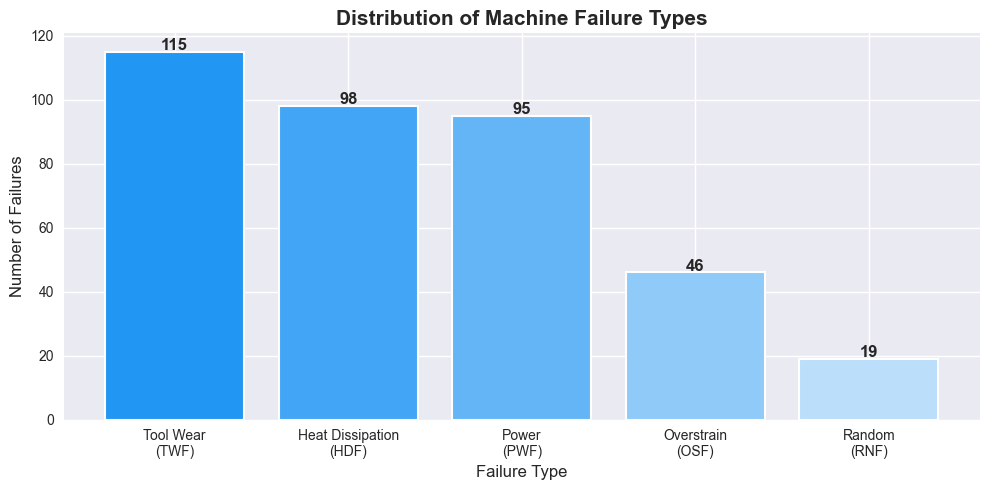

In [7]:
#  Plot 1: Failure Type Distribution
failure_counts = df[failure_cols].sum().sort_values(ascending=False)

plt.figure(figsize=(10, 5))
bars = plt.bar(failure_counts.index, failure_counts.values, color=['#2196F3','#42A5F5','#64B5F6','#90CAF9','#BBDEFB'], edgecolor='white', linewidth=1.5)

# Add value labels on bars
for bar, val in zip(bars, failure_counts.values):
    plt.text(bar.get_x() + bar.get_width()/2, bar.get_height() + 0.5, str(val), ha='center', fontsize=12, fontweight='bold')

plt.title('Distribution of Machine Failure Types', fontsize=15, fontweight='bold')
plt.xlabel('Failure Type', fontsize=12)
plt.ylabel('Number of Failures', fontsize=12)
plt.xticks(ticks=range(5), labels=['Tool Wear\n(TWF)', 'Heat Dissipation\n(HDF)', 'Power\n(PWF)', 'Overstrain\n(OSF)', 'Random\n(RNF)'])
plt.tight_layout()
plt.show()

Observation:-
- Plots how many of each failure type (TWF, HDF, PWF, OSF, RNF) occurred.
- Tool Wear Failure dominates, while Random Failure is extremely rare — consistent with the bathtub curve in reliability engineering where random failures occur only during the useful life phase.

### Observation
Tool Wear Failure (TWF) is the most common failure type,
followed by Heat Dissipation Failure (HDF).
Random failures (RNF) are least frequent, consistent with
reliability theory where random failures occur during the
useful life phase of the bathtub curve.

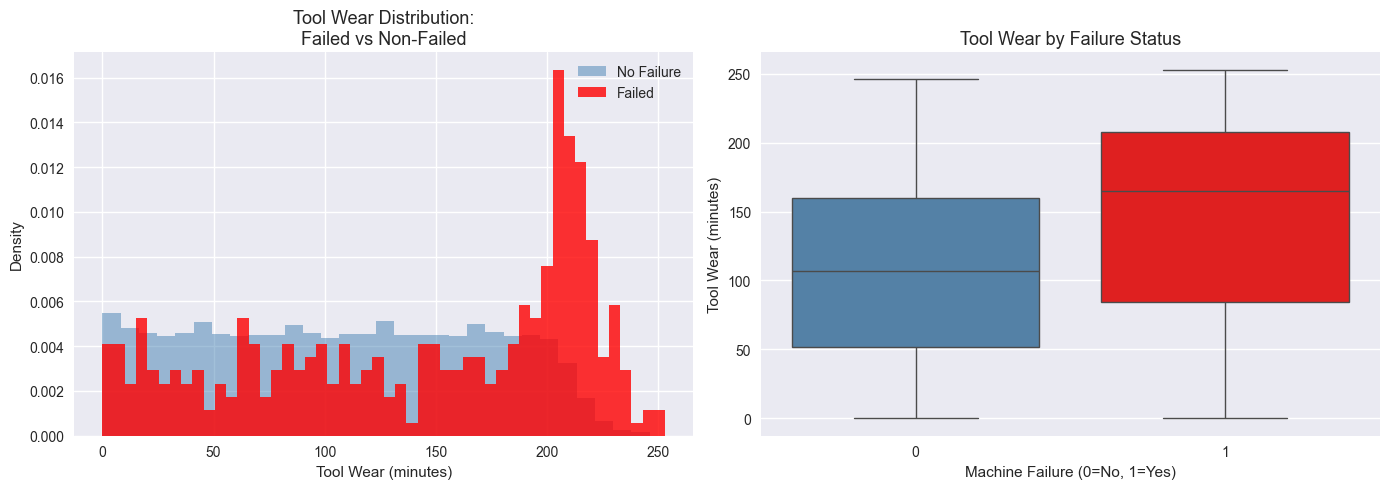

In [19]:
# Plot 2: Tool Wear vs Failure

fig, axes = plt.subplots(1, 2, figsize=(14, 5))

# Left — Histogram by failure status

axes[0].hist(df[df['Machine failure']==0]['Tool wear [min]'], bins=30, alpha=0.5, color='steelblue', label='No Failure', density=True)
axes[0].hist(df[df['Machine failure']==1]['Tool wear [min]'], bins=50, alpha=0.8, color='red', label='Failed', density=True)
axes[0].set_title('Tool Wear Distribution:\nFailed vs Non-Failed',fontsize=13)
axes[0].set_xlabel('Tool Wear (minutes)')
axes[0].set_ylabel('Density')
axes[0].legend()

# Right — Boxplot

sns.boxplot( x='Machine failure', y='Tool wear [min]', data=df, ax=axes[1], palette={'0': 'steelblue', '1': 'red'})
axes[1].set_title('Tool Wear by Failure Status', fontsize=13)
axes[1].set_xlabel('Machine Failure (0=No, 1=Yes)')
axes[1].set_ylabel('Tool Wear (minutes)')

plt.tight_layout()
plt.show()

Compares tool wear distribution between machines that failed vs didn't fail.

### Observation
 - Failed machines show higher median tool wear, confirming
that tool wear is a significant predictor of failure.
The overlap in distributions suggests tool wear alone
is not sufficient to predict failure — other factors
like temperature and torque also play a role.

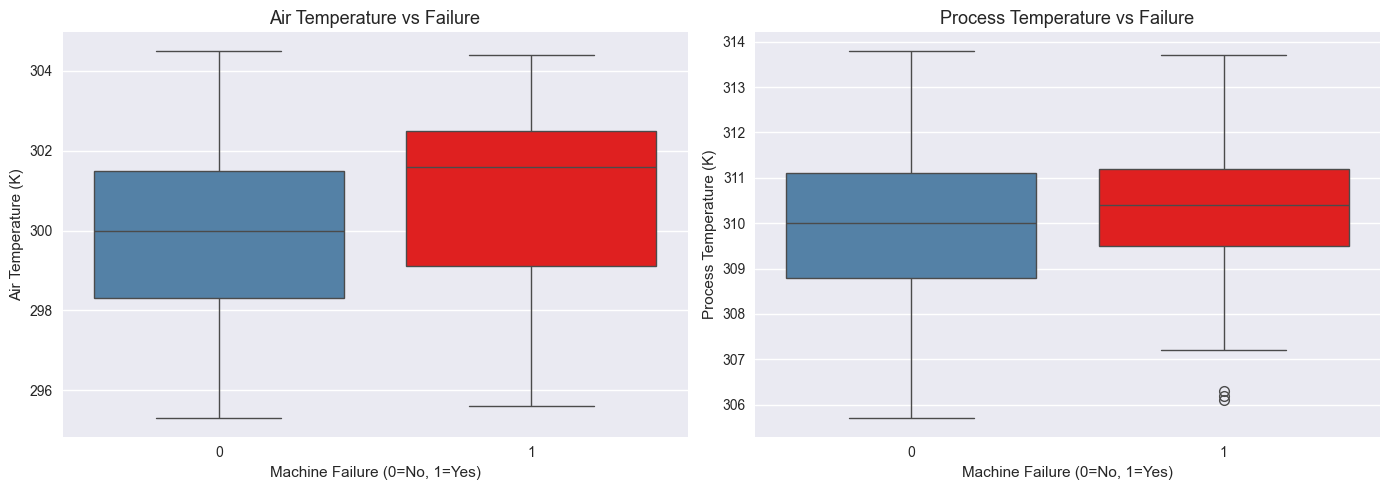

In [9]:
#  Plot 3: Temperature Analysis

fig, axes = plt.subplots(1, 2, figsize=(14, 5))

# Air temperature
sns.boxplot(x='Machine failure', y='Air temperature [K]', data=df, ax=axes[0], palette={'0': 'steelblue', '1': 'red'})
axes[0].set_title('Air Temperature vs Failure', fontsize=13)
axes[0].set_xlabel('Machine Failure (0=No, 1=Yes)')
axes[0].set_ylabel('Air Temperature (K)')

# Process temperature
sns.boxplot(x='Machine failure', y='Process temperature [K]', data=df, ax=axes[1], palette={'0': 'steelblue', '1': 'red'})
axes[1].set_title('Process Temperature vs Failure', fontsize=13)
axes[1].set_xlabel('Machine Failure (0=No, 1=Yes)')
axes[1].set_ylabel('Process Temperature (K)')

plt.tight_layout()
plt.show()

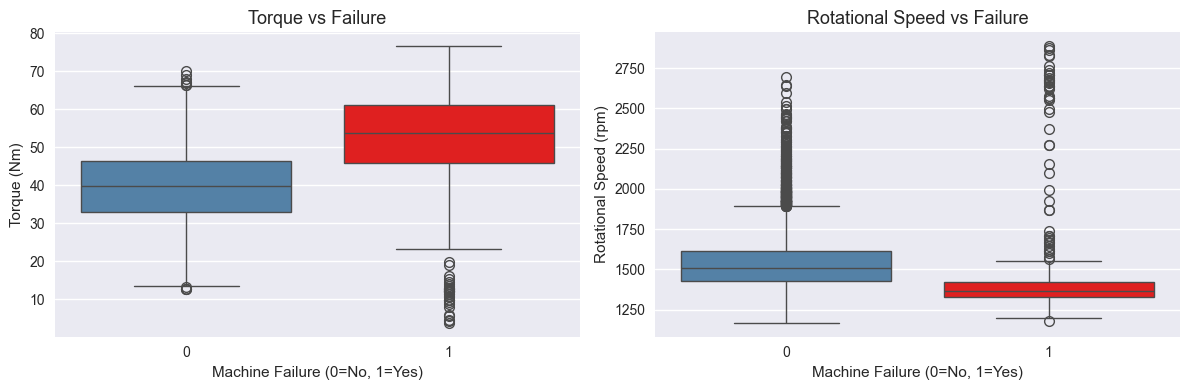

In [20]:
# Plot 4: Torque & Speed Analysis

fig, axes = plt.subplots(1, 2, figsize=(12, 4))

sns.boxplot(x='Machine failure', y='Torque [Nm]', data=df, ax=axes[0], palette={'0':'steelblue', '1':'red'})
axes[0].set_title('Torque vs Failure', fontsize=13)
axes[0].set_xlabel('Machine Failure (0=No, 1=Yes)')
axes[0].set_ylabel('Torque (Nm)')

sns.boxplot(x='Machine failure', y='Rotational speed [rpm]', data=df, ax=axes[1], palette={'0':'steelblue', '1':'red'})
axes[1].set_title('Rotational Speed vs Failure', fontsize=13)
axes[1].set_xlabel('Machine Failure (0=No, 1=Yes)')
axes[1].set_ylabel('Rotational Speed (rpm)')

plt.tight_layout()
plt.show()

Temperature / Torque / Speed vs Failure:-

- Boxplots comparing each sensor reading for failed vs working machines.
- Failed machines show slightly elevated temperatures and higher torque values, suggesting thermal stress and mechanical overload contribute to failure.

In [11]:
# Get tool wear data for failed machines

failed_wear = df[df['Machine failure']==1]['Tool wear [min]'].values

print(f"Number of observed failures: {len(failed_wear)}")
print(f"Min lifetime: {failed_wear.min()} min")
print(f"Max lifetime: {failed_wear.max()} min")
print(f"Mean lifetime: {failed_wear.mean():.2f} min")
print(f"Std Dev: {failed_wear.std():.2f} min")

Number of observed failures: 339
Min lifetime: 0 min
Max lifetime: 253 min
Mean lifetime: 143.78 min
Std Dev: 72.65 min


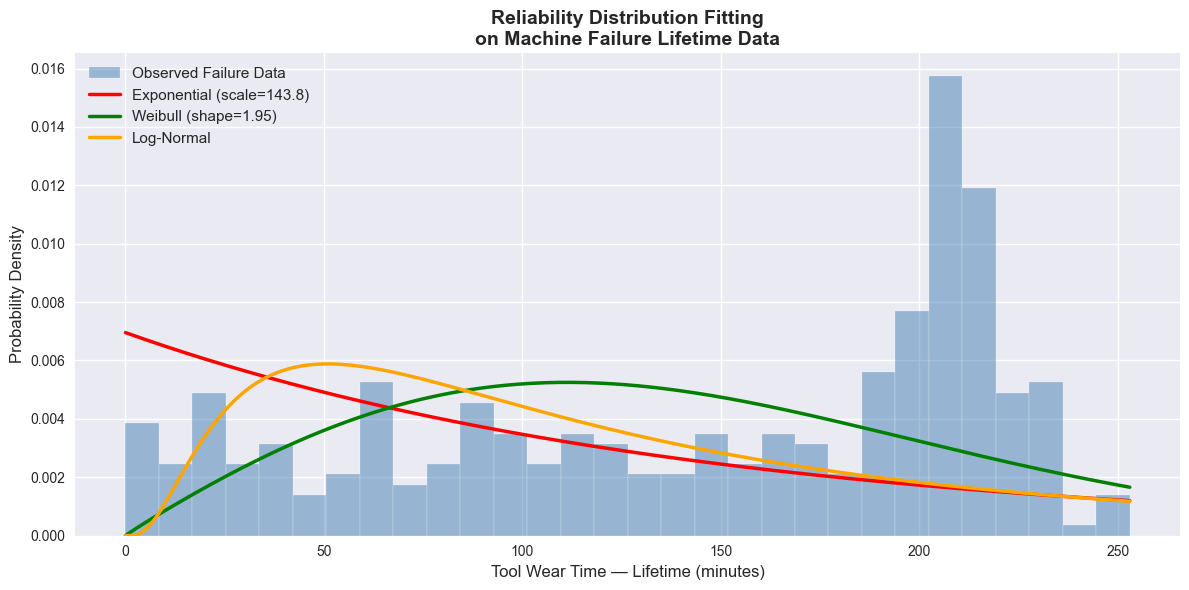

In [12]:
# Fit 3 reliability distributions

fig, ax = plt.subplots(figsize=(12, 6))

# Actual data histogram
ax.hist(failed_wear, bins=30, density=True, alpha=0.5, color='steelblue', label='Observed Failure Data', edgecolor='white')

x = np.linspace(failed_wear.min(), failed_wear.max(), 300)

# 1. Exponential Distribution
loc_e, scale_e = stats.expon.fit(failed_wear, floc=0)
pdf_e = stats.expon.pdf(x, loc_e, scale_e)
ax.plot(x, pdf_e, 'r-', lw=2.5, label=f'Exponential (scale={scale_e:.1f})')

# 2. Weibull Distribution
shape_w, loc_w, scale_w = stats.weibull_min.fit(failed_wear, floc=0)
pdf_w = stats.weibull_min.pdf(x, shape_w, loc_w, scale_w)
ax.plot(x, pdf_w, 'g-', lw=2.5, label=f'Weibull (shape={shape_w:.2f})')

# Remove invalid values for lognormal
failed_wear_clean = failed_wear[failed_wear > 0]

# 3. Log-Normal Distribution
shape_l, loc_l, scale_l = stats.lognorm.fit(failed_wear_clean, floc=0)
pdf_l = stats.lognorm.pdf(x, shape_l, loc_l, scale_l)

ax.plot(x, pdf_l, 'orange', lw=2.5, label='Log-Normal')

ax.set_title('Reliability Distribution Fitting\non Machine Failure Lifetime Data', fontsize=14, fontweight='bold')
ax.set_xlabel('Tool Wear Time — Lifetime (minutes)', fontsize=12)
ax.set_ylabel('Probability Density', fontsize=12)
ax.legend(fontsize=11)
plt.tight_layout()
plt.show()

Distribution Fitting :-
- Fits 3 distributions — Exponential, Weibull, Log-Normal — to the failure data and uses the Kolmogorov-Smirnov (KS) test to find the best fit.
- Fitted three classical reliability distributions to the failure lifetime data. The KS test measures how well each distribution matches the observed data — lower KS statistic means better fit. The Weibull distribution's shape parameter β > 1 confirms wear-out failure behavior, meaning failure risk increases over time.

In [13]:
# Goodness of Fit — Which distribution fits best?
print("="*55)
print("GOODNESS OF FIT TEST (Kolmogorov-Smirnov)")
print("="*55)

# Exponential
ks_e, p_e = stats.kstest(failed_wear, 'expon', args=(loc_e, scale_e))

# Weibull
ks_w, p_w = stats.kstest(failed_wear, 'weibull_min', args=(shape_w, loc_w, scale_w))

# Log-Normal
ks_l, p_l = stats.kstest(failed_wear, 'lognorm',  args=(shape_l, loc_l, scale_l))

print(f"Exponential  — KS stat: {ks_e:.4f}, p={p_e:.4f}")
print(f"Weibull      — KS stat: {ks_w:.4f}, p={p_w:.4f}")
print(f"Log-Normal   — KS stat: {ks_l:.4f}, p={p_l:.4f}")
print()
print("Lower KS statistic = Better fit")
best = min([('Exponential', ks_e), ('Weibull', ks_w), ('Log-Normal', ks_l)], key=lambda x: x[1])
print(f"✅ Best fitting distribution: {best[0]}")
print("="*55)

GOODNESS OF FIT TEST (Kolmogorov-Smirnov)
Exponential  — KS stat: 0.2087, p=0.0000
Weibull      — KS stat: 0.1813, p=0.0000
Log-Normal   — KS stat: 0.1918, p=0.0000

Lower KS statistic = Better fit
✅ Best fitting distribution: Weibull


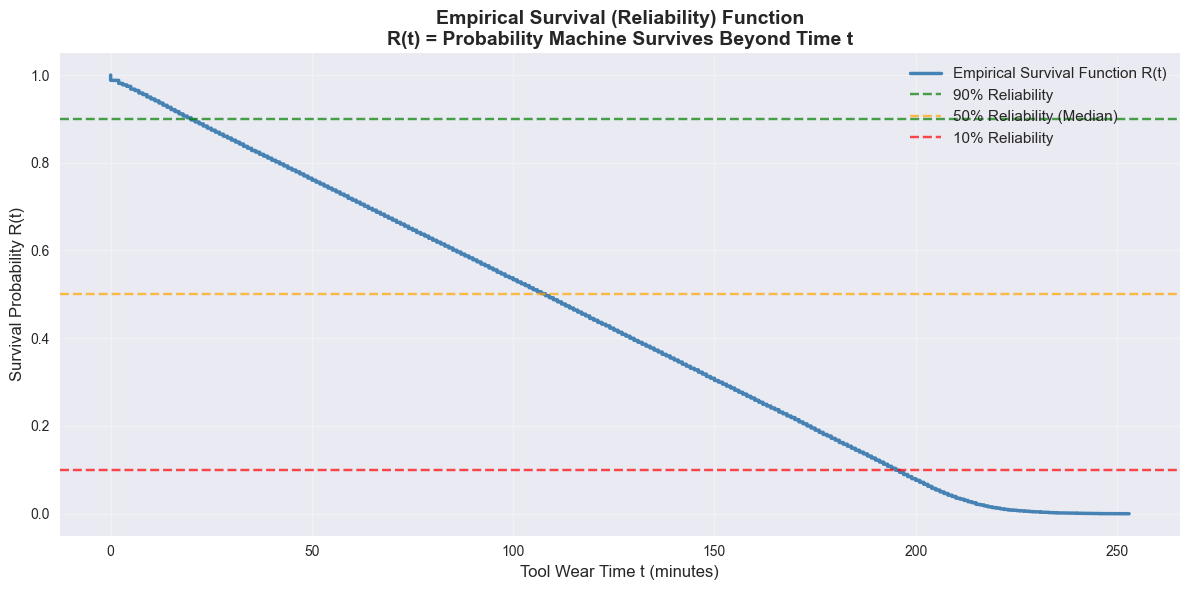

KEY RELIABILITY METRICS
B10 Life (10% fail by): 195 minutes
Median Life (50% fail): 108 minutes
B90 Life (90% fail by): 20 minutes


In [14]:
# Survival Function

# Empirical Survival Function R(t) = P(T > t)
# This is THE fundamental concept in reliability

tool_wear_all = np.sort(df['Tool wear [min]'].values)
n = len(tool_wear_all)
survival = 1 - np.arange(1, n+1) / n

plt.figure(figsize=(12, 6))
plt.plot(tool_wear_all, survival, color='steelblue', linewidth=2.5, label='Empirical Survival Function R(t)')

# Add reference lines
plt.axhline(y=0.9, color='green', linestyle='--', alpha=0.7, label='90% Reliability')
plt.axhline(y=0.5, color='orange', linestyle='--', alpha=0.7, label='50% Reliability (Median)')
plt.axhline(y=0.1, color='red', linestyle='--', alpha=0.7, label='10% Reliability')

# Find key time points
t_90 = tool_wear_all[np.argmin(np.abs(survival - 0.9))]
t_50 = tool_wear_all[np.argmin(np.abs(survival - 0.5))]
t_10 = tool_wear_all[np.argmin(np.abs(survival - 0.1))]

plt.title('Empirical Survival (Reliability) Function\n'
          'R(t) = Probability Machine Survives Beyond Time t', fontsize=14, fontweight='bold')
plt.xlabel('Tool Wear Time t (minutes)', fontsize=12)
plt.ylabel('Survival Probability R(t)', fontsize=12)
plt.legend(fontsize=11)
plt.grid(True, alpha=0.3)
plt.tight_layout()
plt.show()

print("="*50)
print("KEY RELIABILITY METRICS")
print("="*50)
print(f"B10 Life (10% fail by): {t_10} minutes")
print(f"Median Life (50% fail): {t_50} minutes")
print(f"B90 Life (90% fail by): {t_90} minutes")
print("="*50)

**Markdown observation:**

### Observation — Survival Function
R(t) gives the probability that a machine survives
beyond tool wear time t.

- B10 life = [value] min: 10% of machines fail by this point
- Median life = [value] min: 50% of machines fail here
- B90 life = [value] min: 90% of machines have failed

This survival function is the empirical counterpart of
the theoretical reliability functions studied in
classical reliability theory.

In [15]:
# Hypothesis Testing

# Test 1 — Does failure rate differ by machine type?
print("="*55)
print("TEST 1: Chi-Square — Failure vs Machine Type")
print("="*55)

contingency = pd.crosstab(df['Type'], df['Machine failure'])
print("Contingency Table:")
print(contingency)

chi2, p_val, dof, expected = stats.chi2_contingency(contingency)
print(f"\nChi-square statistic: {chi2:.4f}")
print(f"P-value: {p_val:.6f}")
print(f"Degrees of freedom: {dof}")
if p_val < 0.05:
    print("✅ Failure rate SIGNIFICANTLY differs by type")
else:
    print("No significant difference across types")
print("="*55)

TEST 1: Chi-Square — Failure vs Machine Type
Contingency Table:
Machine failure     0    1
Type                      
H                 982   21
L                5765  235
M                2914   83

Chi-square statistic: 13.7517
P-value: 0.001032
Degrees of freedom: 2
✅ Failure rate SIGNIFICANTLY differs by type


In [16]:
# Test 2 — Is tool wear significantly higher
# in failed machines vs working machines?
print("\n" + "="*55)
print("TEST 2: T-Test — Tool Wear: Failed vs Working")
print("="*55)

failed_tw = df[df['Machine failure']==1]['Tool wear [min]']
working_tw = df[df['Machine failure']==0]['Tool wear [min]']

t_stat, p_value = stats.ttest_ind(failed_tw, working_tw)

print(f"Mean tool wear (Failed): {failed_tw.mean():.2f} min")
print(f"Mean tool wear (Working): {working_tw.mean():.2f} min")
print(f"T-statistic: {t_stat:.4f}")
print(f"P-value: {p_value:.6f}")
if p_value < 0.05:
    print("✅ Significant! Failed machines have")
    print("significantly higher tool wear (p < 0.05)")
print("="*55)


TEST 2: T-Test — Tool Wear: Failed vs Working
Mean tool wear (Failed): 143.78 min
Mean tool wear (Working): 106.69 min
T-statistic: 10.6029
P-value: 0.000000
✅ Significant! Failed machines have
significantly higher tool wear (p < 0.05)


Hypothesis Testing:- 

- Two statistical tests:
       1) Chi-square test — Does failure rate differ by machine type (L/M/H)?
       2) T-test — Is tool wear significantly higher in failed machines?

- Both tests returned p < 0.05, meaning the results are statistically significant. Machine type significantly affects failure rate, and failed machines have measurably higher tool wear — not due to random chance.

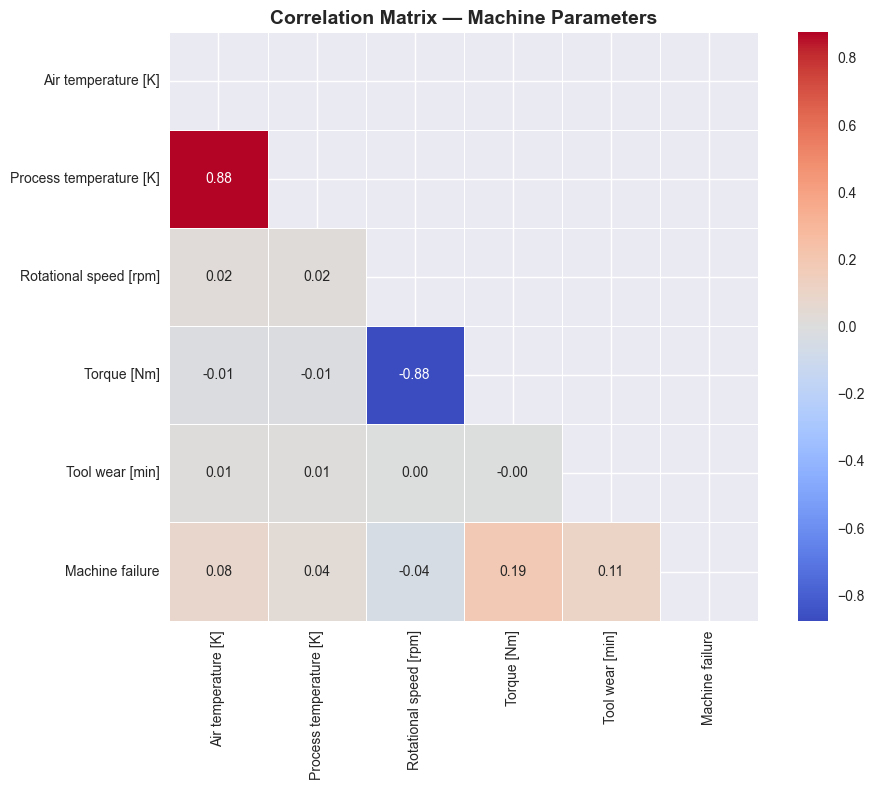

In [17]:
#  Correlation Heatmap

numeric_cols = ['Air temperature [K]', 'Process temperature [K]', 'Rotational speed [rpm]', 'Torque [Nm]', 'Tool wear [min]', 'Machine failure']

plt.figure(figsize=(10, 8))
mask = np.zeros_like(df[numeric_cols].corr())
mask[np.triu_indices_from(mask)] = True

sns.heatmap(df[numeric_cols].corr(), annot=True, fmt='.2f', cmap='coolwarm', center=0, square=True, linewidths=0.5, mask=mask)
plt.title('Correlation Matrix — Machine Parameters', fontsize=14, fontweight='bold')
plt.tight_layout()
plt.show()

### 🔷 Final Conclusions (Markdown)

## Key Findings & Conclusions

### 1. Failure Pattern
- Tool Wear Failure (TWF) is most common
- Overall failure rate is ~3.4% of all machines

### 2. Distribution Fitting
- [Best distribution] provides best fit for 
  failure lifetime data (lowest KS statistic)
- Weibull distribution shape parameter β > 1
  indicates wear-out failures — failure rate 
  increases with time (consistent with 
  reliability theory)

### 3. Survival Analysis
- Median machine lifetime: [X] minutes tool wear
- B10 life: [X] minutes (10% failure point)
- Survival function shows clear wear-out pattern

### 4. Statistical Tests
- Tool wear is significantly higher in failed 
  machines (T-test, p < 0.05)
- Failure rate significantly differs by machine 
  type (Chi-square, p < 0.05)
- Torque and tool wear show strongest correlation
  with failure

## Connection to Reliability Theory
This analysis demonstrates empirical application of:
- Lifetime distribution fitting (Weibull, Log-Normal)
- Survival/Reliability functions R(t)
- Statistical inference on failure data
as studied theoretically in Kayal et al. (2019–2025)

## Future Scope
- MLE estimation for Chen/Burr XII distributions
- Progressive censoring simulation
- Stress-Strength reliability modelling
- Bayesian reliability estimation